# Deep learning for three-dimensional seismic fault prediction using convolutional neural networks 
### Yasir Bashir* , Dilek Yüksel, Begüm Akin, Derin Gezer, Muhsan Ehsan ,Muhammad Khan , and Syed Haroon Ali

### Availability of data
###### Data are available from the corresponding author upon reasonable request, and the codes are available online at the GitHub repository.
### Code availability section
###### Name of the code/library: CNN-fault-prediction
###### Contact: (Email) dryasir.bashir@live.com, ybashir@itu.edu.tr
###### Hardware requirements: Intel(R) Xeon(R) CPU E5-2678 v3 @ 2.50 GHz and an NVIDIA GeForce GTX 1080 Ti GPU.
###### Program language: Python
###### Software required: Anaconda, Jupyter Notebook
###### Program size: 5 Gigabytes
###### The source codes are available for download at: https://github.com/dryasir/CNN-Fault-Prediction 


#### Abstract

##### _Understanding seismic faults is essential for generating prospects, modeling reservoirs, and assessing carbon dioxide storage. Identifying faults in complex tectonic regimes presents significant challenges, especially in areas that have undergone multiple phases of tectonic activity. Even with advances in structural seismic attributes and machine learning, interpreters often rely on manual methods to examine complex fault systems. This work introduces a method for predicting three-dimensional seismic faults using convolutional neural networks (CNNs), effectively overcoming the constraints of conventional interpretation techniques. The research uses CNNs to demonstrate the effectiveness of seismic attributes in training models that identify faults with high accuracy and consistency. This approach, unlike manual interpretation, reduces time, costs, and subjective errors by leveraging automated learning techniques, thereby improving reproducibility and efficiency while reducing interpreter bias. The research highlights the growing importance of solid computational tools in geophysics, especially as seismic datasets become more complex and wider. The approach significantly enhances confidence in artificial intelligence-assisted geological analysis by validating its performance with realworld data. The validation accuracy rises from 0.936 to 0.9436 across configurations, while the validation loss increases from 0.5635 to 0.9941 across diverse patches of the trained model._

# Installing Libraries

This section imports all the necessary Python libraries and modules required for seismic data processing, visualization, interactive widgets, and deep learning model development. These libraries include tools for numerical computations **(numpy)**, image processing **(PIL)**, plotting **(matplotlib)**, handling seismic data **(segyio)**, building neural networks **(tensorflow, keras)**, and creating interactive elements in Jupyter notebooks **(ipywidgets)**.

In [1]:
import tensorflow as tf
from sys import stdout

import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from tensorflow import keras

import os
import sys
import segyio

import ipywidgets as widgets
from IPython.display import display

import numpy as np

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: _multiarray_umath failed to import

ImportError: numpy._core.umath failed to import

Note:
This notebook imports several Python libraries.  If any of these libraries are not installed on your system, you can install them by uncommenting and running the commands below After installation, there's no need to run them again.

In [2]:
#!pip install matplotlib
#!pip install pillow numpy
#!pip install segyio
#!pip install tensorflow
#!pip install ipywidgets
#pip install notebook

# Organizing Seismic Traces

Seismic traces in the SEGY file are stored in an unstructured format, with repeated inline and crossline values. To organize the data, unique inline and crossline values are extracted and used to map each trace to a regular 3D grid. This restructuring is essential for proper analysis and visualization.

In [3]:
file_name = r'C:\Users\user\Downloads'
filename = "Seismic_data.sgy"

with segyio.open(filename, "r", ignore_geometry=True) as segy_file:
    segy_file.mmap()

    inlines = np.array(segy_file.attributes(segyio.TraceField.INLINE_3D)[:])
    crosslines = np.array(segy_file.attributes(segyio.TraceField.CROSSLINE_3D)[:])
    samples = len(segy_file.samples)

    unique_ilines = np.unique(inlines)
    unique_xlines = np.unique(crosslines)

    iline_map = {iline: i for i, iline in enumerate(unique_ilines)}
    xline_map = {xline: i for i, xline in enumerate(unique_xlines)}

    data = np.zeros((len(unique_ilines), len(unique_xlines), samples), dtype=np.float32)

    for i in range(segy_file.tracecount):
        il = iline_map[inlines[i]]
        xl = xline_map[crosslines[i]]
        data[il, xl, :] = segy_file.trace[i]
        
# Normalization step: All data values are scaled to the range between 0 and 1.
data = (data - np.min(data)) / (np.max(data) - np.min(data))

print("Seismic data has been successfully loaded and normalized!")


Seismic data has been successfully loaded and normalized!


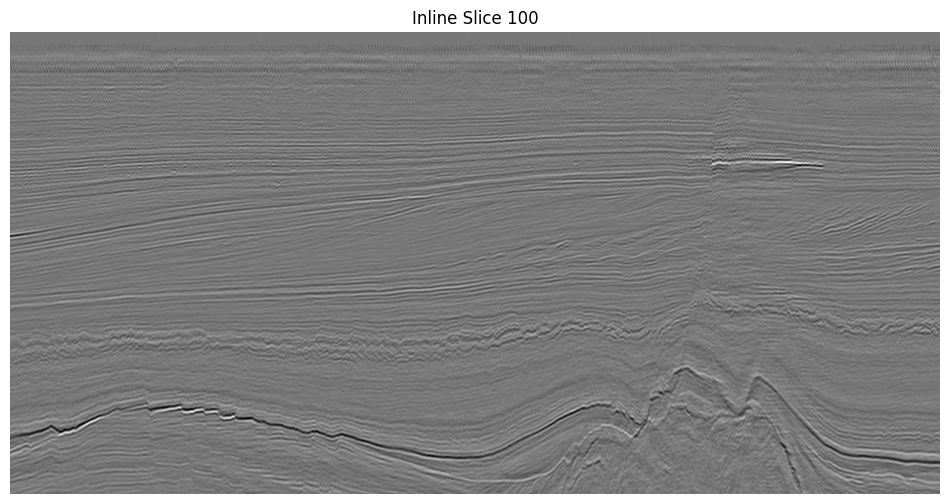

interactive(children=(IntSlider(value=100, continuous_update=False, description='Inline:', max=600, min=100, s…

<function __main__.plot_inline(inline_index)>

In [4]:
# Slider making
inline_slider = widgets.IntSlider(
    value=100,
    min=100,
    max=600,
    step=100,
    description='Inline:',
    continuous_update=False
)

# Define function to update the plot
def plot_inline(inline_index):
    plt.figure(figsize=(12, 6))
    plt.imshow(data[inline_index, :, :].T, cmap='gray', aspect='auto')
    plt.title(f"Inline Slice {inline_index}")
    plt.axis('off')
    plt.show()

# Connect slider to plot function
widgets.interact(plot_inline, inline_index=inline_slider)

In [5]:
#import matplotlib.pyplot as plt
#import ipywidgets as widgets

#inline_index = 100  # Inline number to visualize

#plt.figure(figsize=(12, 6))
#plt.imshow(data[inline_index, :, :].T, cmap='gray', aspect='auto')
#plt.title(f"Inline Slice {inline_index}")
#plt.axis('off')
#plt.show()


In [6]:
# inline_slider = widgets.IntSlider(
#     value=100,
#     min=100,
#     max=500,
#     step=100,
#     description='Inline:',
#     continuous_update=False
# )

# # Define function to update the plot
# def plot_inline(inline_index):
#     plt.figure(figsize=(12, 6))
#     plt.imshow(data[inline_index, :, :].T, cmap='gray', aspect='auto')
#     plt.title(f"Inline Slice {inline_index}")
#     plt.axis('off')
#     plt.show()

# # Connect slider to plot function
# widgets.interact(plot_inline, inline_index=inline_slider)




# Interactive Overlay of Label Masks on Seismic Inline Slices
This code helps us **visualize** seismic data slices together with their corresponding **label masks**. It takes one inline slice from the 3D seismic volume (loaded from a SEGY file) and displays it as a grayscale image. At the same time, it loads a **binary mask** from a **PNG file** where important regions are marked. This mask is used to create a *red-colored overlay*: the red color is applied to the entire image, but only the pixels where the label equals 1 (important areas) are made visible. All other pixels are set to be fully transparent, so **only the red areas appear** on top of the grayscale image. Both the seismic image and the red overlay are combined as **RGBA images**, and the result is displayed using matplotlib. Finally, an *interactive slider* allows the user to scroll through different inline slices and explore how the labels align with the seismic structures.

In [7]:
# Load a label mask for a given inline slice
def load_label(inline):
    folder_path = r'C:\Users\begum\OneDrive\Masaüstü\bitirme\model'
    label_path = f'{folder_path}\\mask_inline_{inline}.png'
    label = Image.open(label_path)
    label.load()
    label = np.asarray(label)[:, :, 3]  # Alpha channel
    return np.where(label > 0.5, 1, 0)



####
from PIL import Image as PILImage
import numpy as np

# Load label first
inline = 600
label = load_label(inline)  # Now label is defined

# Define target size (height, width)
target_height, target_width = 462, 951  # For example

# Convert label (binary mask) to PIL image (0-255 uint8)
label_img = PILImage.fromarray((label * 255).astype(np.uint8))

# Resize label image
label_resized_img = label_img.resize((target_width, target_height), PILImage.NEAREST)

# Convert back to numpy array and binarize again
label_resized = np.asarray(label_resized_img) > 127

print("Original label shape:", label.shape)
print("Resized label shape:", label_resized.shape)

# Assume you already loaded the label mask as a numpy array called `label`
# Example: label = load_label(inline)

# And you know the target size (width, height)
target_height, target_width = 462, 951  # For example, seismic image shape

# Convert label (binary mask) to PIL image (0-255 uint8)
label_img = PILImage.fromarray((label * 255).astype(np.uint8))

# Resize to target size (width, height) using NEAREST neighbor to preserve mask integrity
label_resized_img = label_img.resize((target_width, target_height), PILImage.NEAREST)

# Convert back to numpy array and binarize again
label_resized = np.asarray(label_resized_img) > 127

#print("Original label shape:", label.shape)
print("Resized label shape:", label_resized.shape)


Original label shape: (1224, 3134)
Resized label shape: (462, 951)
Resized label shape: (462, 951)


Plotting inline: 100
Seismic image shape: (462, 951)
Original label shape: (462, 951)


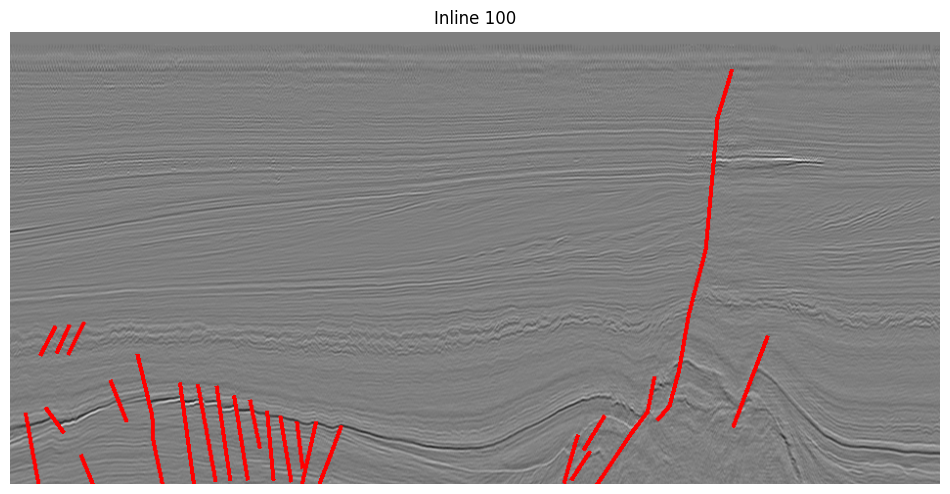

Plot displayed successfully.


interactive(children=(IntSlider(value=100, continuous_update=False, description='Inline:', max=600, min=100, s…

<function __main__.plot_overlay(inline)>

In [8]:
from PIL import Image as PILImage
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets  # assuming widgets are imported

def plot_overlay(inline):
    print(f"Plotting inline: {inline}")
    
    label = load_label(inline)
    if label is None:
        print(f"Label for inline {inline} could not be loaded.")
        return
    
    image = data[inline, :, :].T  # Transpose so time is vertical
    
    print(f"Seismic image shape: {image.shape}")
    print(f"Original label shape: {label.shape}")
    
    # Resize label mask to seismic image size if shapes differ
    if label.shape != image.shape:
        label_img = PILImage.fromarray((label * 255).astype(np.uint8))
        label_img = label_img.resize((image.shape[1], image.shape[0]), PILImage.NEAREST)
        label = np.asarray(label_img) > 127
        print(f"Resized label shape: {label.shape}")

    tmax, xmax = image.shape
    
    # Create RGBA label overlay using resized label
    label_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    label_rgb[:, :, 0] = 255  # red channel
    label_rgb[:, :, 1] = 255 - 255 * label  # green channel (inverse)
    label_rgb[:, :, 2] = 255 - 255 * label  # blue channel (inverse)
    label_rgb[:, :, 3] = 255 * label  # alpha channel (transparency)
    
    img = PILImage.fromarray(label_rgb, mode='RGBA')
    
    # Create RGBA seismic image
    image_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    image_rgb[:, :, 0:3] = (255 * image[..., None]).astype('uint8')
    image_rgb[:, :, 3] = 255
    background = PILImage.fromarray(image_rgb, mode='RGBA')
    
    # Overlay label on seismic image
    background.paste(img, (0, 0), img)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(background)
    plt.title(f"Inline {inline}")
    plt.axis('off')
    plt.show()
    print("Plot displayed successfully.")

# Slider widget for interaction
inline_slider = widgets.IntSlider(
    value=100,
    min=100,
    max=600,
    step=100,
    description='Inline:',
    continuous_update=False
)

widgets.interact(plot_overlay, inline=inline_slider)


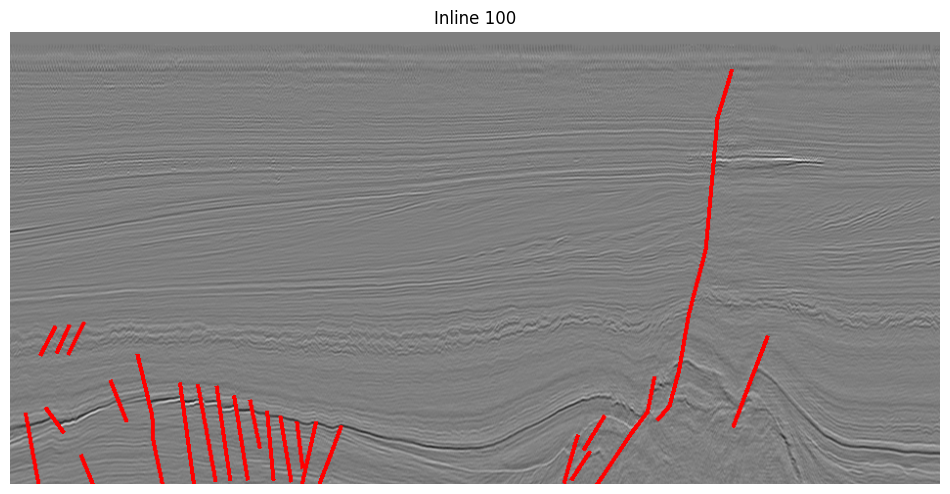

interactive(children=(IntSlider(value=100, continuous_update=False, description='Inline:', max=600, min=100, s…

<function __main__.plot_overlay(inline)>

In [9]:
## convert from markdown to code if you want to run it

#plot_overlay(600)
from PIL import Image as PILImage
import numpy as np
import matplotlib.pyplot as plt

def plot_overlay(inline):
    print(f"Plotting inline: {inline}")
    
    label = load_label(inline)
    if label is None:
        print(f"Label for inline {inline} could not be loaded.")
        return
    
    image = data[inline, :, :].T  # Transpose to get (tmax, xmax)
    
    print(f"Seismic image shape: {image.shape}")
    print(f"Original label shape: {label.shape}")
    
    # Resize label to match seismic image shape if needed
    if label.shape != image.shape:
        label_img = PILImage.fromarray((label * 255).astype(np.uint8))
        label_img = label_img.resize((image.shape[1], image.shape[0]), PILImage.NEAREST)
        label = np.asarray(label_img) > 127
        print(f"Resized label shape: {label.shape}")

    tmax, xmax = image.shape
    
    # Create RGBA label overlay
    label_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    label_rgb[:, :, 0] = 255  # red
    label_rgb[:, :, 1] = 255 - 255 * label  # green
    label_rgb[:, :, 2] = 255 - 255 * label  # blue
    label_rgb[:, :, 3] = 255 * label  # alpha
    
    img = PILImage.fromarray(label_rgb, mode='RGBA')
    
    # Create RGBA seismic image
    image_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    image_rgb[:, :, 0:3] = (255 * image[..., None]).astype('uint8')
    image_rgb[:, :, 3] = 255
    background = PILImage.fromarray(image_rgb, mode='RGBA')
    
    # Overlay and show
    background.paste(img, (0, 0), img)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(background)
    plt.title(f"Inline {inline}")
    plt.axis('off')
    plt.show()
    print("Plot displayed successfully.")
############################################

# Overlay label onto grayscale seismic image
def plot_overlay(inline):
    label = load_label(inline)
    image = data[inline, :, :].T  # Transpose so time is vertical
    tmax, xmax = image.shape

    # Create RGBA label overlay
    label_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    label_rgb[:, :, 0] = 255 #red
    label_rgb[:, :, 1] = 255 - 255 * label #green
    label_rgb[:, :, 2] = 255 - 255 * label #blue
    label_rgb[:, :, 3] = 255 * label #alpha

    img = Image.fromarray(label_rgb, mode='RGBA')

    # Create RGBA seismic image
    image_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    image_rgb[:, :, 0:3] = (255 * image[..., None]).astype('uint8')
    image_rgb[:, :, 3] = 255
    background = Image.fromarray(image_rgb, mode='RGBA')

    # Overlay and show
    background.paste(img, (0, 0), img)
    plt.figure(figsize=(12, 6))
    plt.imshow(background)
    plt.title(f"Inline {inline}")
    plt.axis('off')
    plt.show()

 # Interactive slider
inline_slider = widgets.IntSlider(
     value=100,
     min=100,
     max=600,
     step=100,
     description='Inline:',
     continuous_update=False
 )

# # Display interactive plot
widgets.interact(plot_overlay, inline=inline_slider)


# Patch Extraction for Training and Validation
This function extracts a specified number of square patches (sub-images) from a 2D seismic inline slice and its corresponding binary label mask. It is designed to prepare training and validation data for a CNN by focusing on areas where the label mask indicates meaningful features (such as faults).

**How it works:** 

Takes as **input** a seismic data slice (data) and a label mask (label) of the same size.
**Extracts** square patches of a given size (e.g., 64x64 pixels) randomly from the data.
Only accepts patches that contain **enough labeled pixels**, based on a minimum pixel count threshold to ensure relevant features are present.
If the data and label dimensions are mismatched in orientation, the function transposes the data to align them properly.

Continues **sampling** patches until the requested number of valid patches is collected.

Returns two numpy arrays:

**X** — extracted seismic data patches, shaped for CNN input with a channel dimension

**Y** — corresponding label patches, binary masks of the same shape

This approach ensures the training set includes **meaningful examples** for the network to learn from, **improving** the detection of relevant geological features in the seismic data.

In [10]:
inline = 600
seismic_slice = data[inline, :, :]  # orijinal slice, (462, 951) olabilir
label = load_label(inline)           # orijinal label

# Burada ekle:
if seismic_slice.shape != label.shape:
    # İkisi aynı shape ve orientation'a gelsin
    seismic_slice = seismic_slice.T


In [11]:
def patchify(data, label, size, number, threshold):
    if data.shape != label.shape:
        data = data.T

    t_max, x_max = label.shape
    X = np.zeros((number, size, size, 1))
    Y = np.zeros((number, size, size, 1))

    n = 0
    attempts = 0
    max_attempts = number * 20

    while n < number and attempts < max_attempts:
        attempts += 1

        if x_max < size or t_max < size:
            print(f"ERROR: Patch size {size} exceeds image size ({t_max}, {x_max})")
            break

        x = random.randint(size // 2, x_max - size // 2 - 1)
        t = random.randint(size // 2, t_max - size // 2 - 1)

        patch_data = data[t - size // 2 : t + size // 2,
                          x - size // 2 : x + size // 2]
        patch_label = label[t - size // 2 : t + size // 2,
                            x - size // 2 : x + size // 2]

        if patch_data.shape != (size, size) or patch_label.shape != (size, size):
            continue

        if np.count_nonzero(patch_label) > threshold:
            X[n, :, :, 0] = patch_data
            Y[n, :, :, 0] = patch_label
            n += 1

    if n < number:
        print(f"WARNING: Only extracted {n} patches out of {number} after {attempts} attempts.")

    return X, Y


inline = 600
seismic_slice = data[inline, :, :]  # shape (t, x)

label = load_label(inline)  # shape (orig_height, orig_width)

from PIL import Image as PILImage
import numpy as np

def resize_label_to_seismic(label, seismic_slice):
    tmax, xmax = seismic_slice.shape  # (height, width)
    label_img = PILImage.fromarray((label * 255).astype(np.uint8))
    label_img = label_img.resize((xmax, tmax), PILImage.NEAREST)  # resize expects (width, height)
    label_resized = np.asarray(label_img) > 127
    if label_resized.shape != seismic_slice.shape:
        label_resized = label_resized.T
    return label_resized.astype(np.uint8)


# Usage
label_resized = resize_label_to_seismic(label, seismic_slice)

# Settings
size       = 64
threshold  = 0
num_train  = 8000
num_val    = 2000

X, Y = patchify(seismic_slice, label_resized, size, num_train, threshold)
print(f"Extracted {X.shape[0]} training patches.")


###############################33


#########################33
print(f"Seismic slice shape: {seismic_slice.shape}")
print(f"Label resized shape: {label_resized.shape}")
print(f"Patch size: {size}")


Extracted 8000 training patches.
Seismic slice shape: (951, 462)
Label resized shape: (951, 462)
Patch size: 64


In [12]:
# Settings
size       = 64
threshold  = 0
num_train  = 8000
num_val    = 2000

# Function to resize label mask to seismic slice shape
from PIL import Image as PILImage
import numpy as np

def resize_label_to_seismic(label, seismic_slice):
    tmax, xmax = seismic_slice.shape  # height, width
    label_img = PILImage.fromarray((label * 255).astype(np.uint8))
    label_img = label_img.resize((xmax, tmax), PILImage.NEAREST)
    label_resized = np.asarray(label_img) > 127
    if label_resized.shape != seismic_slice.shape:
        label_resized = label_resized.T
    return label_resized.astype(np.uint8)

# --- Validation ---
label   = load_label(300)
seismic = data[300, ...]
label = resize_label_to_seismic(label, seismic)  # resize label here
X_val, Y_val = patchify(seismic, label, size, num_val, threshold)

# --- Training ---
inlines = [100, 200, 400, 500, 600]
patches_per_inline = num_train // len(inlines)

X_train = np.zeros((num_train, size, size, 1))
Y_train = np.zeros((num_train, size, size, 1))

n = 0
for inline in inlines:
    label = load_label(inline)
    seismic = data[inline, ...]
    label = resize_label_to_seismic(label, seismic)  # resize label here
    X_part, Y_part = patchify(seismic, label, size, patches_per_inline, threshold)
    X_train[n : n + patches_per_inline, ...] = X_part
    Y_train[n : n + patches_per_inline, ...] = Y_part
    n += patches_per_inline

print(f"Extracted {X_val.shape[0]} validation patches.")

# Inside your training loop:
print(f"Extracted {X_part.shape[0]} patches from inline {inline}")

# After training loop:
print(f"Total training patches extracted: {X_train.shape[0]}")


Extracted 2000 validation patches.
Extracted 1600 patches from inline 600
Total training patches extracted: 8000


In [13]:
## convert to code to run


# Settings
size       = 64
threshold  = 0
num_train  = 8000
num_val    = 2000

# --- Validation ---
label   = load_label(300)
seismic = data[300, ...]
if seismic.shape != label.shape:
    seismic = seismic.T
X_val, Y_val = patchify(seismic, label, size, num_val, threshold)

# --- Training ---
inlines = [100, 200, 400, 500, 600]
patches_per_inline = num_train // len(inlines)

X_train = np.zeros((num_train, size, size, 1))
Y_train = np.zeros((num_train, size, size, 1))

n = 0
for inline in inlines:
    label = load_label(inline)
    seismic = data[inline, ...]
    if seismic.shape != label.shape:
        seismic = seismic.T
    X_part, Y_part = patchify(seismic, label, size, patches_per_inline, threshold)
    X_train[n : n + patches_per_inline, ...] = X_part
    Y_train[n : n + patches_per_inline, ...] = Y_part
    n += patches_per_inline


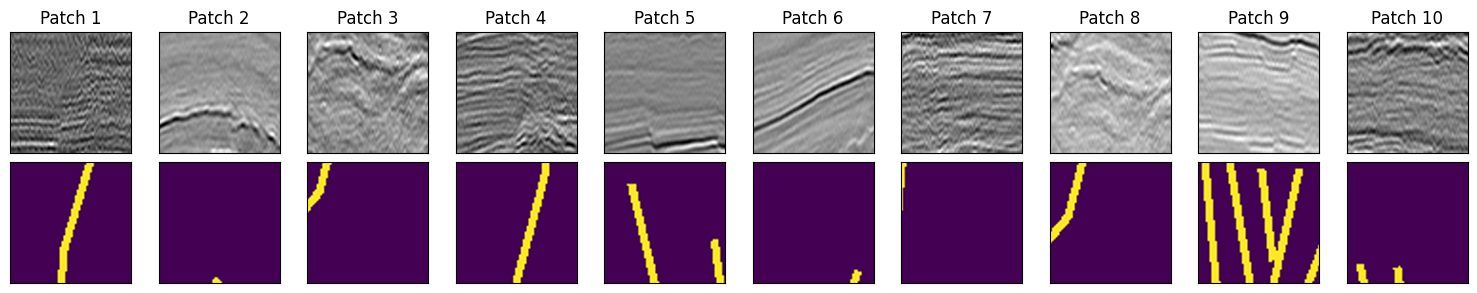

In [14]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 10, figsize=(15, 3))

k = 0  # Patch index

# --- Plot 10 seismic image patches ---
for m in range(10):
    axs[0, m].imshow(X_train[k, :, :, 0],  # Plot grayscale patch
                     interpolation='spline16',
                     cmap=plt.cm.gray,
                     aspect=1)
    axs[0, m].set_xticks([])
    axs[0, m].set_yticks([])
    axs[0, m].set_title(f'Patch {k+1}')  # Add patch title above each seismic patch
    k += 1

k = 0  # Reset index

# --- Plot the corresponding 10 label masks ---
for m in range(10):
    axs[1, m].imshow(Y_train[k, :, :, 0],  # Plot label mask (binary)
                     interpolation='spline16',
                     aspect=1)
    axs[1, m].set_xticks([])
    axs[1, m].set_yticks([])
    k += 1

plt.tight_layout()
plt.show()



In [15]:
import tensorflow as tf

# ---- Encoder block: Downsampling ----
def down_block(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(x)
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(c)
    p = tf.keras.layers.MaxPool2D((2, 2), (2, 2))(c)
    return c, p

# ---- Decoder block: Upsampling ----
def up_block(x, skip, filters, kernel_size=(3, 3), padding="same", strides=1):
    us = tf.keras.layers.UpSampling2D((2, 2))(x)
    concat = tf.keras.layers.Concatenate()([us, skip])
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(concat)
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(c)
    return c

# ---- Bottleneck block ----
def bottleneck(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(x)
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(c)
    return c

# ---- Full UNet architecture ----
def UNet(input_size):
    f = [16, 32, 64, 128,256]  # Number of filters at each level   

    inputs = tf.keras.layers.Input((input_size, input_size, 1))

    # Encoder (contracting path)
    c1, p1 = down_block(inputs, f[0])  # 64 -> 32
    c2, p2 = down_block(p1, f[1])      # 32 -> 16
    c3, p3 = down_block(p2, f[2])      # 16 -> 8
    c4, p4 = down_block(p3, f[3])      # 8 -> 4

    # Bottleneck
    bn = bottleneck(p4, f[4])          # 4 -> 4

    # Decoder (expanding path)
    u1 = up_block(bn, c4, f[3])        # 4 -> 8
    u2 = up_block(u1, c3, f[2])        # 8 -> 16
    u3 = up_block(u2, c2, f[1])        # 16 -> 32
    u4 = up_block(u3, c1, f[0])        # 32 -> 64

    # Output layer: 1 channel with sigmoid for binary segmentation
    outputs = tf.keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(u4)

    model = tf.keras.models.Model(inputs, outputs)
    return model

# ---- Instantiate and compile the model ----
size = 64  # Example input patch size
model = UNet(size)

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])  # Or use "acc" for shorthand


### I run because of my ram, this is a short filter no 256

import tensorflow as tf

# ---- Encoder block: Downsampling ----
def down_block(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(x)
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(c)
    p = tf.keras.layers.MaxPool2D((2, 2), (2, 2))(c)
    return c, p

# ---- Decoder block: Upsampling ----
def up_block(x, skip, filters, kernel_size=(3, 3), padding="same", strides=1):
    us = tf.keras.layers.UpSampling2D((2, 2))(x)
    concat = tf.keras.layers.Concatenate()([us, skip])
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(concat)
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(c)
    return c

# ---- Bottleneck block ----
def bottleneck(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(x)
    c = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(c)
    return c

# ---- Full UNet architecture ----
def UNet(input_size):
    f = [16, 32, 64, 128]  # Now 4 levels, no 5th

    inputs = tf.keras.layers.Input((input_size, input_size, 1))

    # Encoder (contracting path)
    c1, p1 = down_block(inputs, f[0])  # 64 -> 32
    c2, p2 = down_block(p1, f[1])      # 32 -> 16
    c3, p3 = down_block(p2, f[2])      # 16 -> 8
    c4, p4 = down_block(p3, f[3])      # 8 -> 4

    # Bottleneck - use last filter in f (f[3]) now
    bn = bottleneck(p4, f[3])          # 4 -> 4

    # Decoder (expanding path)
    u1 = up_block(bn, c4, f[3])        # 4 -> 8
    u2 = up_block(u1, c3, f[2])        # 8 -> 16
    u3 = up_block(u2, c2, f[1])        # 16 -> 32
    u4 = up_block(u3, c1, f[0])        # 32 -> 64

    outputs = tf.keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(u4)

    model = tf.keras.models.Model(inputs, outputs)
    return model


# ---- Instantiate and compile the model ----
size = 64  # Example input patch size
model = UNet(size)

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])  # Or use "acc" for shorthand

In [16]:
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_val shape:", X_val.shape)
print("Y_val shape:", Y_val.shape)


X_train shape: (8000, 64, 64, 1)
Y_train shape: (8000, 64, 64, 1)
X_val shape: (2000, 64, 64, 1)
Y_val shape: (2000, 64, 64, 1)


In [17]:
history = model.fit(X_train,
                    Y_train,
                    validation_data=(X_val, Y_val),
                    epochs=5)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 312ms/step - accuracy: 0.9403 - loss: 0.2572 - val_accuracy: 0.9401 - val_loss: 0.2038
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 79s 317ms/step - accuracy: 0.9570 - loss: 0.1539 - val_accuracy: 0.9401 - val_loss: 0.1982
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 79s 317ms/step - accuracy: 0.9569 - loss: 0.1297 - val_accuracy: 0.9393 - val_loss: 0.2227
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 319ms/step - accuracy: 0.9644 - loss: 0.0970 - val_accuracy: 0.9368 - val_loss: 0.2710
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 79s 318ms/step - accuracy: 0.9746 - loss: 0.0653 - val_accuracy: 0.9266 - val_loss: 0.2853


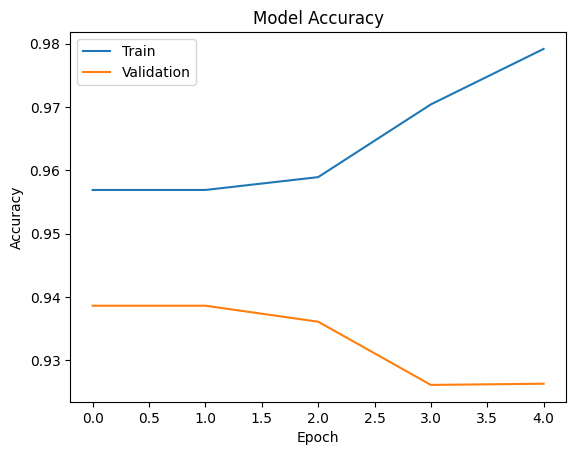

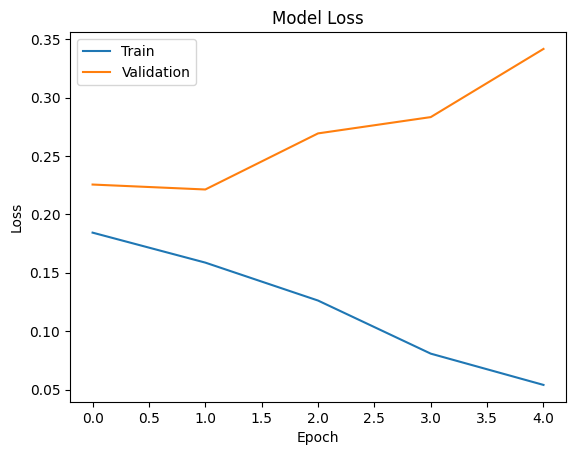

In [33]:
# --- Plot accuracy over training epochs ---
# NOTE: Change 'acc' to 'accuracy' if needed
plt.plot(history.history['accuracy'])           # Training accuracy
plt.plot(history.history['val_accuracy'])       # Validation accuracy
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# --- Plot loss over training epochs ---
plt.plot(history.history['loss'])               # Training loss
plt.plot(history.history['val_loss'])           # Validation loss
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [34]:
#!pip install scikit-learn
print("Y_train mean:", np.mean(Y_train))
print("Y_val mean:", np.mean(Y_val))
print("X_train range:", X_train.min(), "to", X_train.max())



Y_train mean: 0.043092254638671876
Y_val mean: 0.0613760986328125
X_train range: 0.0 to 0.8886684775352478


In [35]:
#!pip install scikit-learn

In [36]:
!{sys.executable} -m pip list | findstr scikit-learn
import sys
print("Python executable:", sys.executable)


scikit-learn                 1.6.1Python executable: C:\Users\begum\.conda\envs\tf310\python.exe



63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step


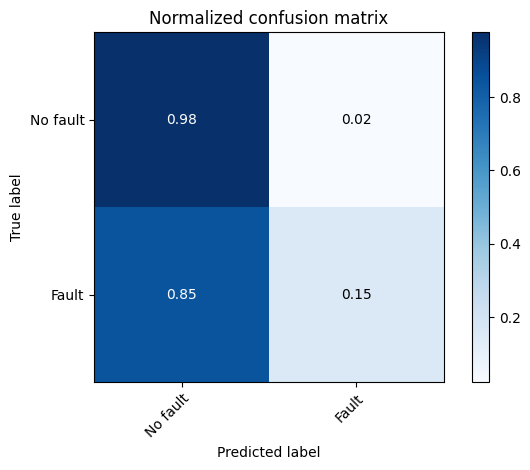

In [37]:
from sklearn.metrics import confusion_matrix

# Predict on validation set
Y_pred = model.predict(X_val)
Y_true = Y_val

# Initialize total confusion matrix for binary classification: [TN, FP], [FN, TP]
cm = np.zeros((2, 2))

# Loop through each patch in the validation set
for n in range(Y_true.shape[0]):
    # Flatten both prediction and ground truth masks to 1D
    # Round predictions to binary values (0 or 1)
    y_true = Y_true[n, :, :, 0].round().flatten().astype(int)
    y_pred = Y_pred[n, :, :, 0].round().flatten().astype(int)

    # Compute confusion matrix for the current patch
    cm_batch = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # Accumulate results
    cm += cm_batch


# --- Plot styling ---
cmap = plt.cm.Blues         # Color map for the heatmap
normalize = True            # Whether to normalize the matrix
title = 'Normalized confusion matrix'
classes = ['No fault', 'Fault']  # Class labels

# --- Normalize the confusion matrix by row (true label) ---
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# --- Create the figure and heatmap ---
fig, ax = plt.subplots()
im = ax.imshow(cm_norm, interpolation='nearest', cmap=cmap)
ax.figure.colorbar(im, ax=ax)  # Add color scale bar

# --- Configure axis ticks and labels ---
ax.set(
    xticks=np.arange(cm_norm.shape[1]),
    yticks=np.arange(cm_norm.shape[0]),
    xticklabels=classes,
    yticklabels=classes,
    title=title,
    ylabel='True label',
    xlabel='Predicted label'
)

# --- Rotate x-axis labels for better readability ---
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# --- Add numerical values inside each cell ---
fmt = '.2f' if normalize else 'd'
thresh = cm_norm.max() / 2.  # Threshold for text color contrast
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, format(cm_norm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black")

# --- Final layout adjustment ---
fig.tight_layout()
plt.show()

# Application
Now we can apply our model to the entire image to see how well it has learned to recognize salt structures in our seismic image:

In [40]:
def tile(data, wsize, dt, dx):
    t_max, x_max = data.shape
    n_patch = (t_max // dt + 1) * (x_max // dx + 1)
    data_patch = np.zeros((n_patch, wsize, wsize, 1))
    n = 0
    for t in range(0, t_max, dt):
        for x in range(0, x_max, dx):
            if t_max - t < wsize and x_max - x < wsize:
                data_patch[n, :, :, 0] = data[t_max - wsize:t_max, x_max - wsize:x_max]
            elif x_max - x < wsize:
                data_patch[n, :, :, 0] = data[t:t + wsize, x_max - wsize:x_max]
            elif t_max - t < wsize:
                data_patch[n, :, :, 0] = data[t_max - wsize:t_max, x:x + wsize]
            else:
                data_patch[n, :, :, 0] = data[t:t + wsize, x:x + wsize]
            n += 1
    return data_patch

def merge(data_patch, t_max, x_max, wsize, dt, dx):
    data_new = np.zeros((t_max, x_max, 1))
    count = np.zeros((t_max, x_max, 1))
    n = 0
    for t in range(0, t_max, dt):
        for x in range(0, x_max, dx):
            if t_max - t < wsize and x_max - x < wsize:
                data_new[t_max - wsize:t_max, x_max - wsize:x_max, 0] += data_patch[n, :, :, 0]
                count[t_max - wsize:t_max, x_max - wsize:x_max, 0] += 1
            elif x_max - x < wsize:
                data_new[t:t + wsize, x_max - wsize:x_max, 0] += data_patch[n, :, :, 0]
                count[t:t + wsize, x_max - wsize:x_max, 0] += 1
            elif t_max - t < wsize:
                data_new[t_max - wsize:t_max, x:x + wsize, 0] += data_patch[n, :, :, 0]
                count[t_max - wsize:t_max, x:x + wsize, 0] += 1
            else:
                data_new[t:t + wsize, x:x + wsize, 0] += data_patch[n, :, :, 0]
                count[t:t + wsize, x:x + wsize, 0] += 1
            n += 1
    return data_new / count


In [42]:
def plot_overlay(image, prediction):
    import numpy as np
    from PIL import Image as PILImage
    import matplotlib.pyplot as plt

    tmax, xmax = image.shape

    # Label (prediction) binarize et (örnek eşik 0.5)
    label = (prediction > 0.5).astype(np.uint8)

    # RGBA label overlay oluştur
    label_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    label_rgb[:, :, 0] = 255  # kırmızı kanal
    label_rgb[:, :, 1] = 255 - 255 * label  # yeşil kanal (inverse)
    label_rgb[:, :, 2] = 255 - 255 * label  # mavi kanal (inverse)
    label_rgb[:, :, 3] = 255 * label         # alpha kanalı (şeffaflık)

    img = PILImage.fromarray(label_rgb, mode='RGBA')

    # Orijinal görüntü RGBA formatına çevir
    image_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    image_rgb[:, :, 0:3] = (255 * image[..., None]).astype('uint8')
    image_rgb[:, :, 3] = 255
    background = PILImage.fromarray(image_rgb, mode='RGBA')

    # Overlay uygula
    background.paste(img, (0, 0), img)

    plt.figure(figsize=(12, 6))
    plt.imshow(background)
    plt.axis('off')
    plt.show()


55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step


<Figure size 1000x1000 with 0 Axes>

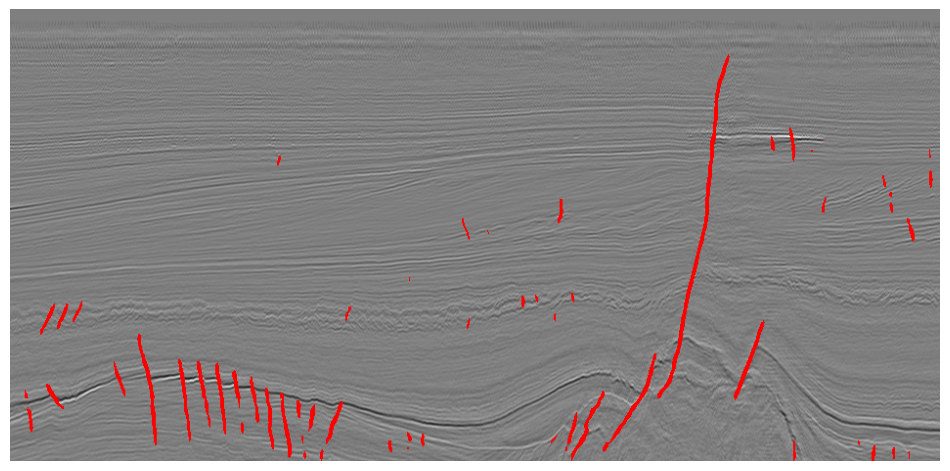

55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step


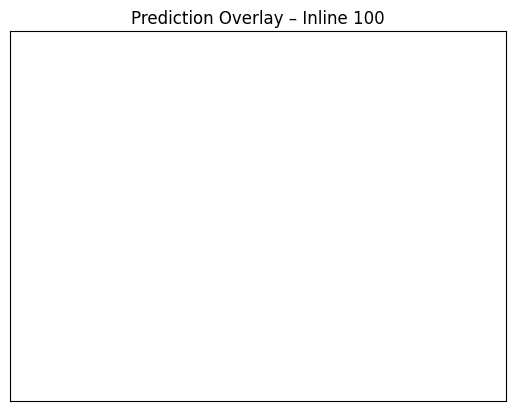

<Figure size 1000x1000 with 0 Axes>

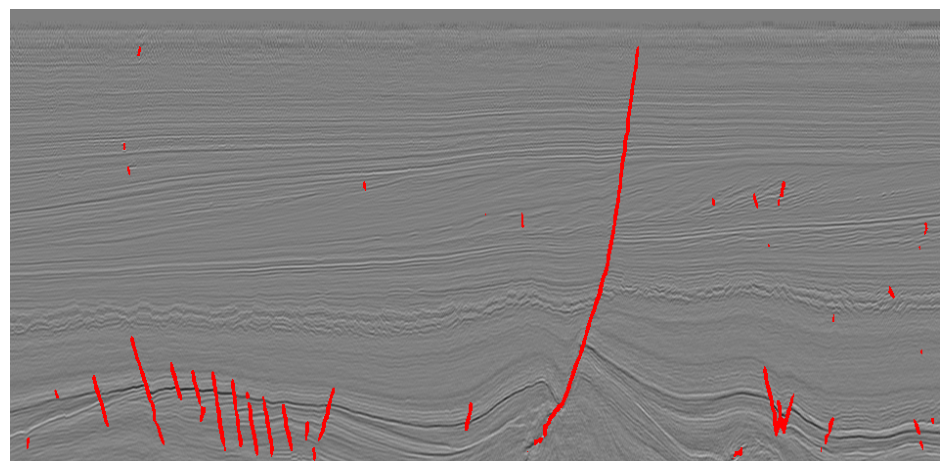

55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step


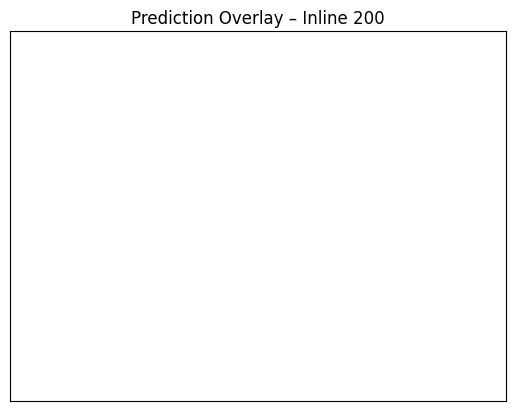

<Figure size 1000x1000 with 0 Axes>

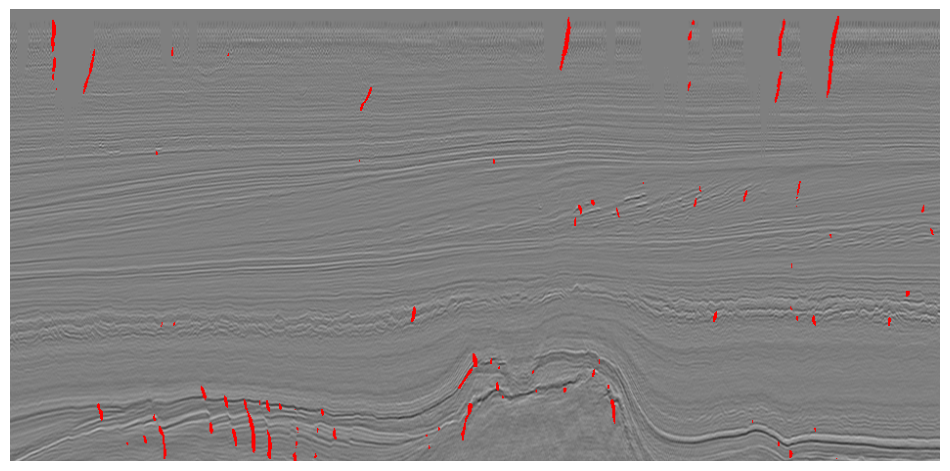

55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step


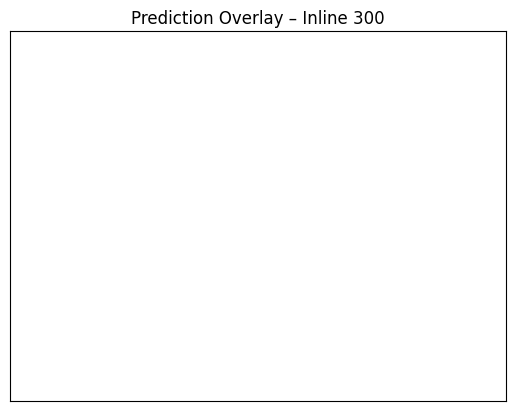

<Figure size 1000x1000 with 0 Axes>

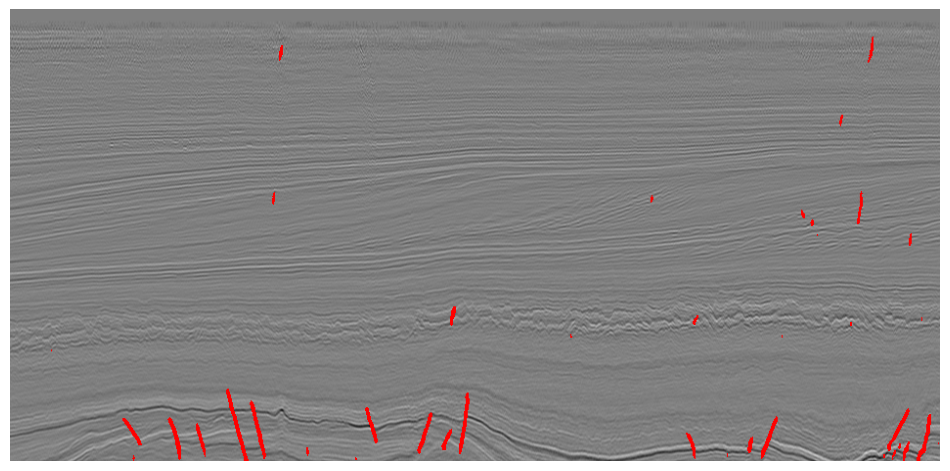

55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step


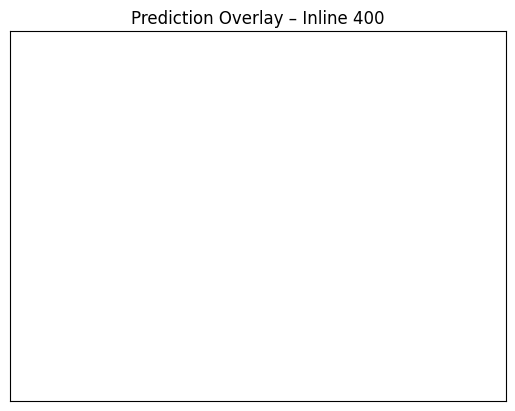

<Figure size 1000x1000 with 0 Axes>

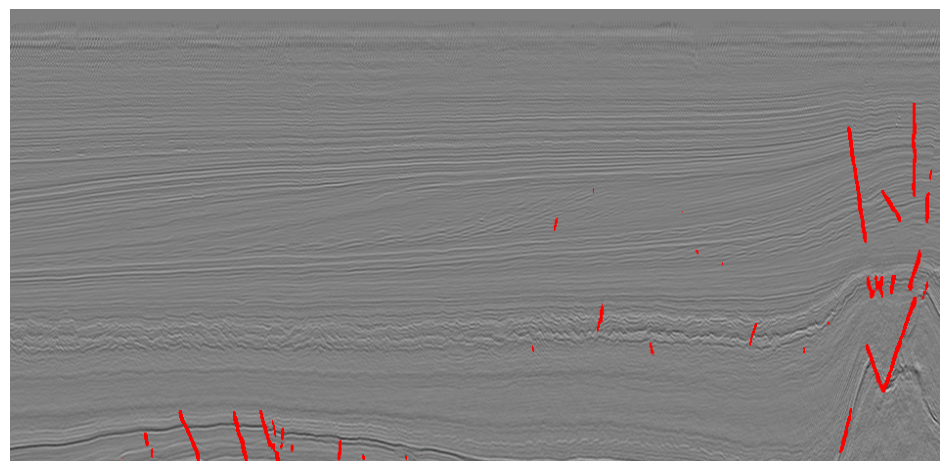

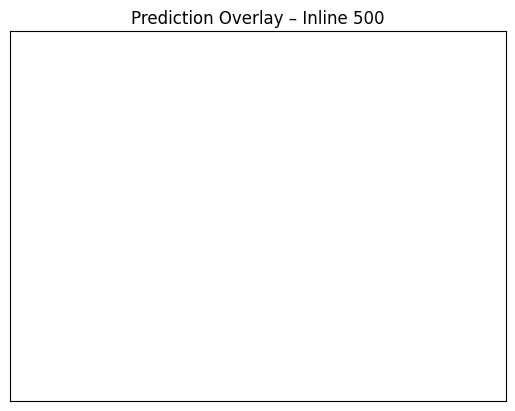

In [44]:
# 1. plot_overlay fonksiyonu (iki argümanlı)
def plot_overlay(image, prediction):
    import numpy as np
    from PIL import Image as PILImage
    import matplotlib.pyplot as plt

    tmax, xmax = image.shape

    label = (prediction > 0.5).astype(np.uint8)

    label_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    label_rgb[:, :, 0] = 255
    label_rgb[:, :, 1] = 255 - 255 * label
    label_rgb[:, :, 2] = 255 - 255 * label
    label_rgb[:, :, 3] = 255 * label

    img = PILImage.fromarray(label_rgb, mode='RGBA')

    image_rgb = np.zeros((tmax, xmax, 4), dtype='uint8')
    image_rgb[:, :, 0:3] = (255 * image[..., None]).astype('uint8')
    image_rgb[:, :, 3] = 255
    background = PILImage.fromarray(image_rgb, mode='RGBA')

    background.paste(img, (0, 0), img)

    plt.figure(figsize=(12, 6))
    plt.imshow(background)
    plt.axis('off')
    plt.show()

# 2. Daha önce verdiğim tab widget kodunu çalıştır (model.predict ve patch'lar ile)

import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

dt = 16
dx = 16
size = 64

_, t_max, x_max = data.shape

tab = widgets.Tab()
outputs = [widgets.Output() for _ in range(5)]
tab.children = outputs

for i in range(5):
    tab.set_title(i, f"Inline {100 + 100*i}")

    with outputs[i]:
        plt.figure(figsize=(10, 10))

        inline_idx = 100 + 100 * i
        inline_data = data[inline_idx, :, :].T

        data_tiles = tile(inline_data, size, dt, dx)
        result_tiles = model.predict(data_tiles)
        result = merge(result_tiles, inline_data.shape[0], inline_data.shape[1], size, dt, dx)

        plot_overlay(inline_data, result[:, :, 0])

        plt.title(f'Prediction Overlay – Inline {inline_idx}')
        plt.xticks([])
        plt.yticks([])

display(tab)


In [45]:
print("Prediction min, max, mean:", result.min(), result.max(), result.mean())


Prediction min, max, mean: 2.9224735936336035e-08 0.9825546741485596 0.02444796463019903
